In [1]:
from pathlib import Path

import duckdb
import geopandas as gpd
import pandas as pd
from shapely import wkt

PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"

In [2]:
bldg = gpd.read_file(
    DATA_INTERIM / "sevilla_buildings_voxcity.gpkg"
)

boundary = gpd.read_file(
    DATA_RAW / "sevilla_boundary.gpkg"
)

print(bldg.crs)
print(boundary.crs)

EPSG:4326
EPSG:4326


In [3]:
boundary_proj = boundary.to_crs(boundary.estimate_utm_crs())

centroid = boundary_proj.geometry.centroid.iloc[0]

test_area_proj = gpd.GeoDataFrame(
    geometry=[centroid.buffer(1000).envelope],
    crs=boundary_proj.crs
)

test_area_3035 = test_area_proj.to_crs(3035)

test_area_3035.total_bounds

array([2907211.33460592, 1737476.96042585, 2909493.89221817,
       1739799.74111545])

In [4]:
xmin, ymin, xmax, ymax = test_area_3035.total_bounds

print(xmin, ymin, xmax, ymax)

2907211.334605925 1737476.960425845 2909493.892218169 1739799.7411154527


In [5]:
con = duckdb.connect()

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

con.execute("INSTALL spatial;")
con.execute("LOAD spatial;")

con.execute("SET s3_endpoint='s3.eubucco.com';")
con.execute("SET s3_url_style='path';")
con.execute("SET s3_region='eu';")
con.execute("SET s3_access_key_id='';")
con.execute("SET s3_secret_access_key='';")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [6]:
s3_path = "s3://eubucco/v0.2/buildings/parquet/*/*.parquet"

query = f"""
SELECT
    id,
    region_id,
    city_id,
    height,
    floors,
    type,
    subtype,
    height_source,
    geometry_source,
    ST_AsText(geometry) AS geometry_wkt
FROM read_parquet(
    '{s3_path}',
    hive_partitioning = true
)
WHERE
    region_id LIKE 'ES%'
    AND bbox.xmin <= {xmax}
    AND bbox.xmax >= {xmin}
    AND bbox.ymin <= {ymax}
    AND bbox.ymax >= {ymin}
"""

df_eubucco = con.execute(query).df()

print(df_eubucco.shape)
df_eubucco.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(6170, 10)


,id,region_id,city_id,height,floors,type,subtype,height_source,geometry_source,geometry_wkt
0,073ce52857ac4a37-0,ES618,ES41091,9.7,2.2,non-residential,public,estimated,osm,"POLYGON ((2908251.102828033 1737950.903891081,..."
1,1c6a12e12b69421b-0,ES618,ES41091,4.9,1.1,non-residential,industrial,estimated,osm,POLYGON ((2908875.949731552 1737687.0242095536...
2,2826b48ef6cf4c8c-0,ES618,ES41091,7.6,1.7,residential,apartment,estimated,osm,"POLYGON ((2908013.772063268 1737689.778391007,..."
3,32ce17483e1d4082-0,ES618,ES41091,15.0,6.1,non-residential,industrial,estimated,osm,POLYGON ((2907886.7847800693 1738654.186391786...
4,3f5e5808ec604f9d-0,ES618,ES41091,4.3,1.0,non-residential,industrial,estimated,osm,POLYGON ((2909312.4435121357 1739425.173983838...


In [7]:
eubucco = gpd.GeoDataFrame(
    df_eubucco.drop(columns="geometry_wkt"),
    geometry=df_eubucco["geometry_wkt"].apply(wkt.loads),
    crs="EPSG:3035"
)

eubucco = gpd.clip(
    eubucco,
    test_area_3035
)

print(len(eubucco))

4298


In [8]:
eubucco["height"].describe()

count    4298.000000
mean       10.583527
std         5.021683
min         3.300000
25%         7.500000
50%         9.800000
75%        12.600000
max        40.400000
Name: height, dtype: float64

In [9]:
eubucco["height_source"].value_counts(dropna=False)

height_source
estimated    4298
Name: count, dtype: int64

In [10]:
eubucco["geometry_source"].value_counts(dropna=False)

geometry_source
gov-spain    4284
osm            14
Name: count, dtype: int64

In [11]:
print(
    "Height coverage:",
    eubucco["height"].notna().mean() * 100,
    "%"
)

Height coverage: 100.0 %


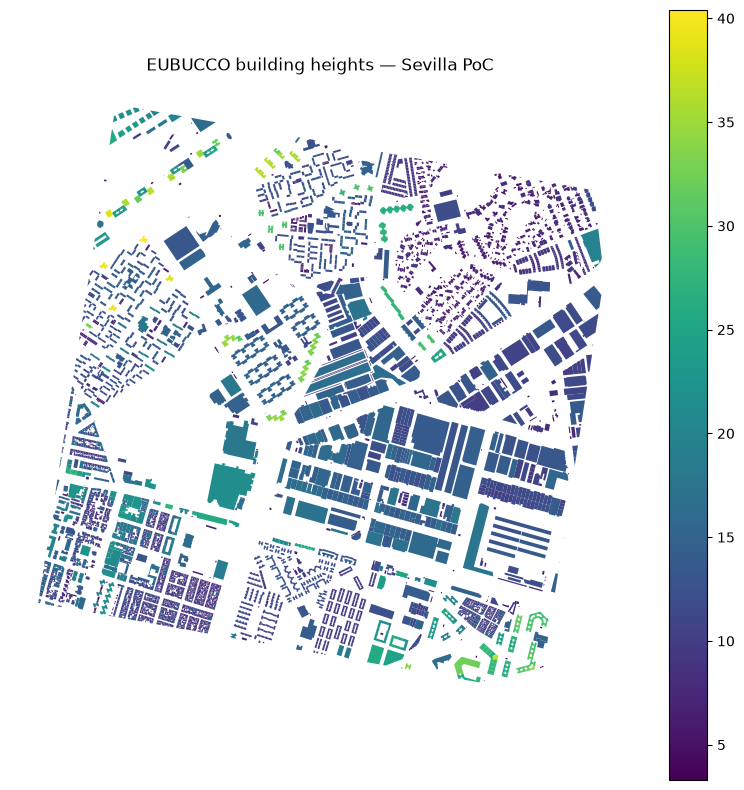

In [12]:
ax = eubucco.plot(
    column="height",
    figsize=(10, 10),
    legend=True
)

ax.set_title("EUBUCCO building heights — Sevilla PoC")
ax.set_axis_off()

In [13]:
eubucco.to_file(
    DATA_INTERIM / "sevilla_eubucco_buildings.gpkg",
    driver="GPKG"
)

In [14]:
len(eubucco)

4298

In [15]:
eubucco["height"].describe()

count    4298.000000
mean       10.583527
std         5.021683
min         3.300000
25%         7.500000
50%         9.800000
75%        12.600000
max        40.400000
Name: height, dtype: float64

In [16]:
eubucco["height_source"].value_counts(dropna=False)

height_source
estimated    4298
Name: count, dtype: int64

In [17]:
eubucco["geometry_source"].value_counts(dropna=False)

geometry_source
gov-spain    4284
osm            14
Name: count, dtype: int64

In [18]:
eubucco_wgs84 = eubucco.to_crs(4326)

In [19]:
eubucco_wgs84[["height", "geometry"]].head()

,height,geometry
4695,9.2,"POLYGON ((-5.95493 37.38329, -5.95485 37.38329..."
650,4.6,"POLYGON ((-5.95768 37.38322, -5.95767 37.38326..."
3368,11.1,"POLYGON ((-5.95787 37.38328, -5.9578 37.38327,..."
5706,11.2,"POLYGON ((-5.95741 37.38343, -5.95741 37.38345..."
5705,11.5,"POLYGON ((-5.95758 37.38345, -5.95758 37.38346..."


In [20]:
print("Missing heights:", eubucco_wgs84["height"].isna().sum())
print("Invalid geometries:", (~eubucco_wgs84.geometry.is_valid).sum())

Missing heights: 0
Invalid geometries: 0


In [21]:
eubucco_clean = eubucco_wgs84[
    eubucco_wgs84["height"].notna()
    & eubucco_wgs84.geometry.notna()
    & eubucco_wgs84.geometry.is_valid
].copy()

print(len(eubucco_clean))

4298


In [22]:
eubucco_clean["id"] = range(1, len(eubucco_clean) + 1)
eubucco_clean["min_height"] = 0.0

VoxCity imported successfully


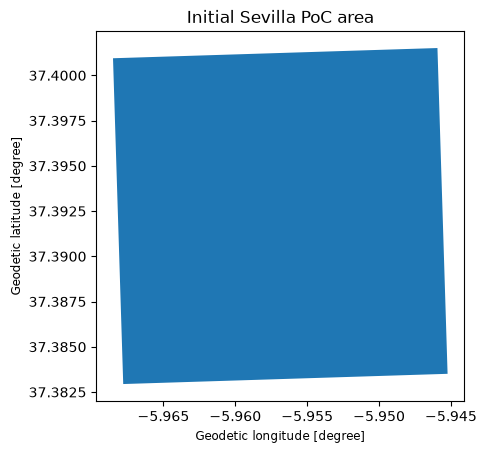

INFO | voxcity.voxcity.generator.api | Auto-selecting data sources for: building_source, land_cover_source, canopy_height_source, dem_source, building_complementary_source


Loading formatted geocoded file...


INFO | voxcity.voxcity.generator.api | Detected country for ROI center (-5.9569, 37.3922): Spain
INFO | voxcity.voxcity.generator.api | Selected data sources:
INFO | voxcity.voxcity.generator.api | - Buildings(base)=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - Buildings(comp)=Microsoft Building Footprints | https://github.com/microsoft/GlobalMLBuildingFootprints
INFO | voxcity.voxcity.generator.api | - LandCover=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - Canopy=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - DEM=Flat
INFO | voxcity.voxcity.generator.api | - ComplementHeight=10
INFO | voxcity.voxcity.utils.cache | Using cached load_gdf_from_openstreetmap result (e6de0f4d9bc39caafaae780cb001e825.pkl)
INFO | voxcity.voxcity.utils.cache | Using cached load_land_cover_gdf_from_osm result (d6fd8d8d3e27ab94ddbc30de899a9b54.pkl)
INFO | voxcity.voxcity.utils.cache | Using


  • Land Cover:  OpenStreetMap
  • Building:    OpenStreetMap
  • Canopy:      OpenStreetMap
  • DEM:         Flat
------------------------------------------------------------
Downloading... (this may take a moment)
  ✓ Dem complete (1/4)
  ✓ Building complete (2/4)


INFO | voxcity.voxcity.downloader.osm | Overpass attempt failed: server error (HTTP 504) from https://overpass-api.de/api/interpreter
INFO | voxcity.voxcity.downloader.osm | Overpass attempt failed: timeout after 60s from https://overpass.kumi.systems/api/interpreter
INFO | voxcity.voxcity.downloader.osm | Overpass endpoint unreachable, marking dead for this call: https://overpass.openstreetmap.ru/api/interpreter (HTTPSConnectionPool(host='overpass.openstreetmap.ru', port=443): Max retries exceeded with url: /api/interpreter?data=%0A++++++++%5Bout%3Ajson%5D%3B%0A++++++++%28%0A++++++++++node%5B%22natural%22%3D%22tree%22%5D%2837.38294295915931%2C-5.96850346486674%2C37.40151128213675%2C-5.9452312992316525%29%3B%0A++++++++++way%5B%22natural%22%3D%22wood%22%5D%2837.38294295915931%2C-5.96850346486674%2C37.40151128213675%2C-5.9452312992316525%29%3B%0A++++++++++way%5B%22landuse%22%3D%22forest%22%5D%2837.38294295915931%2C-5.96850346486674%2C37.40151128213675%2C-5.9452312992316525%29%3B%0A++++++

  ✓ Land Cover complete (3/4)


INFO | voxcity.voxcity.downloader.osm | Overpass attempt failed: timeout after 60s from https://overpass.kumi.systems/api/interpreter
INFO | voxcity.voxcity.downloader.osm | Retry 3/4: waiting 20.0s before next attempt...


  Downloaded 716 individual trees and 6 tree polygons from OSM
  Downloaded 722 trees from OSM
  Created canopy grids: (412, 412)
  ✓ Canopy complete (4/4)
------------------------------------------------------------
All downloads complete!



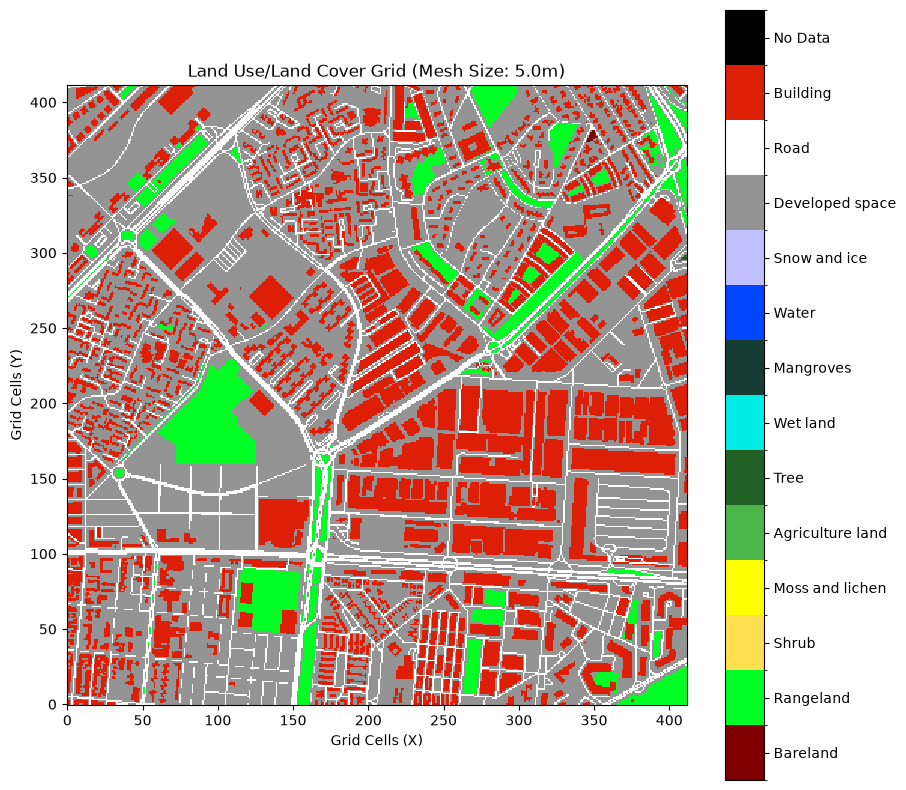

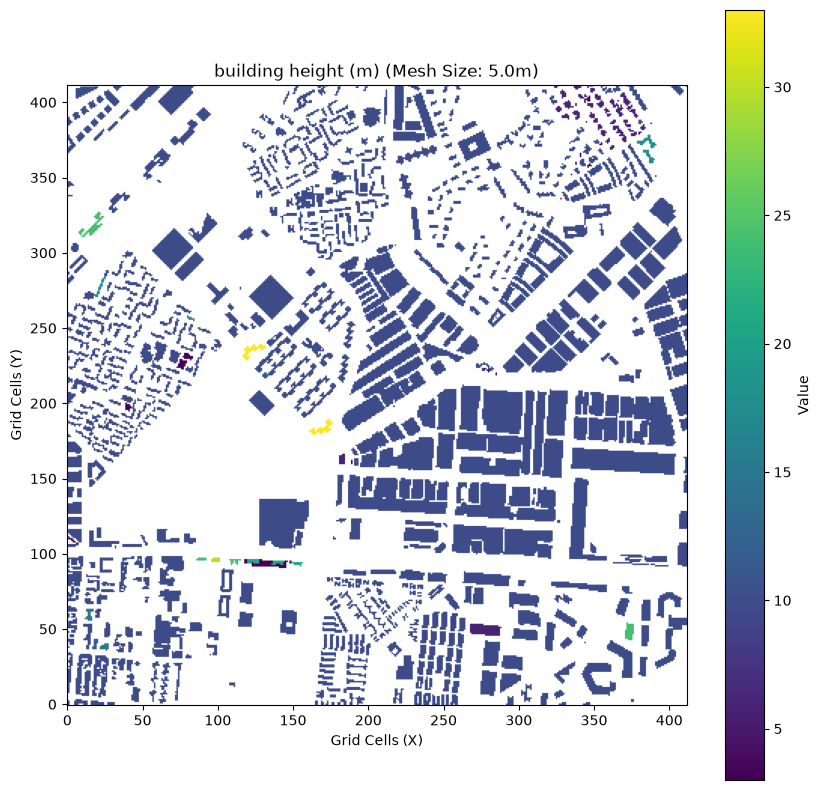

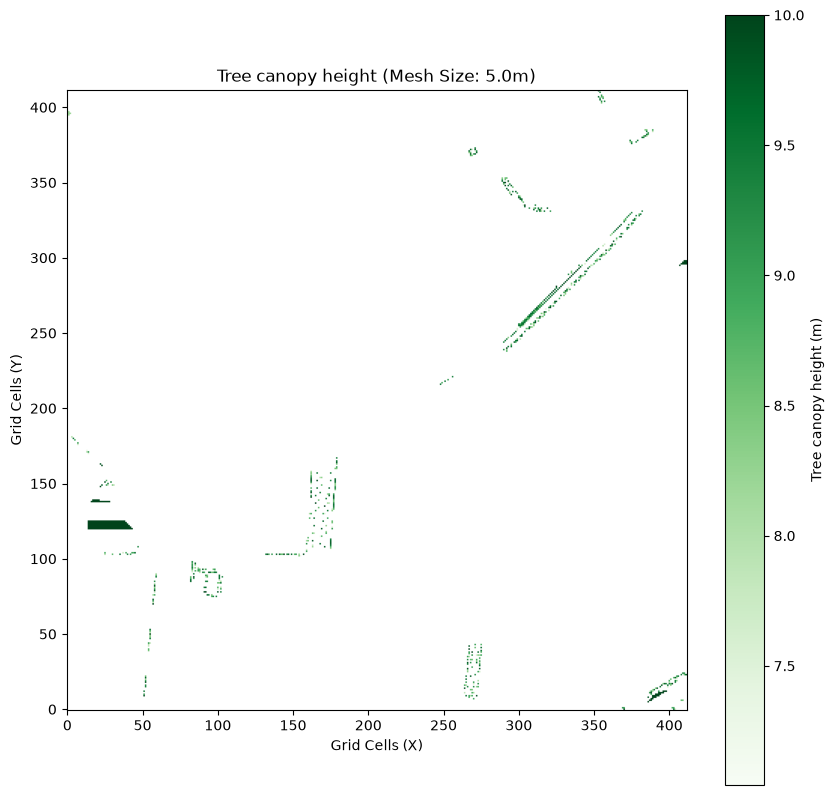

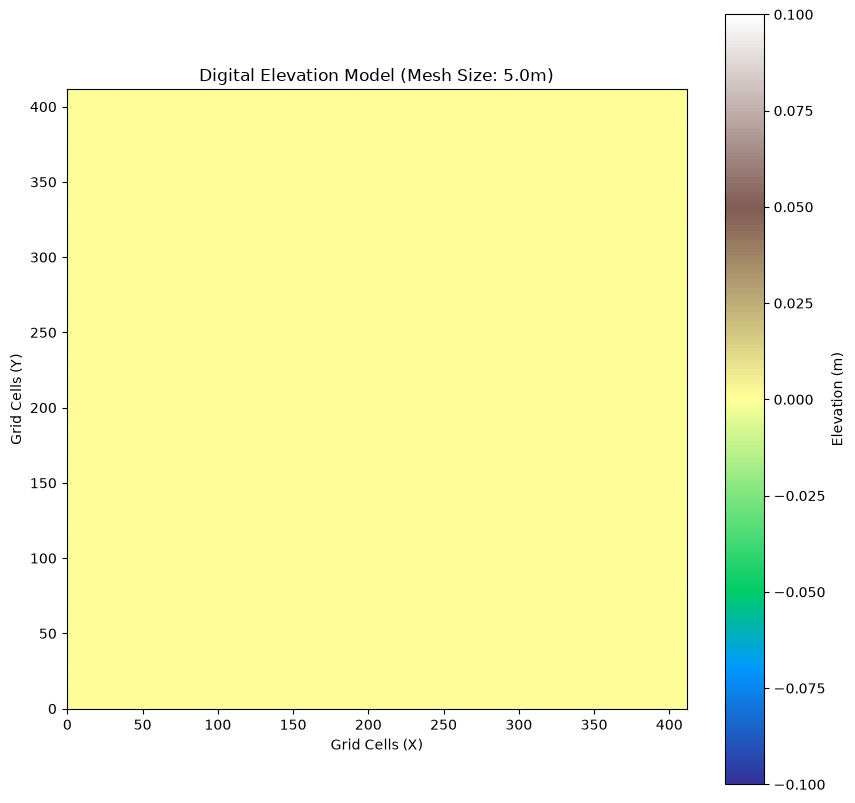

INFO | voxcity.voxcity.generator.voxelizer | Generating 3D voxel data
INFO | voxcity.voxcity.generator.voxelizer | 
Voxel Grid Semantic Codes:
  -3 : Building volume
  -2 : Tree canopy (vegetation)
  -1 : Ground/Subsurface
  >=1: Land cover class at ground surface (see Land Cover Classes)

INFO | voxcity.voxcity.generator.voxelizer | 
VoxCity Standard Land Cover Classes (1-based indices, used in voxel grids):
--------------------------------------------------
   1: Bareland           - Bare soil, rocks, desert
   2: Rangeland          - Grassland, pasture
   3: Shrub              - Shrubland, bushes
   4: Agriculture land   - Cropland, farmland
   5: Tree               - Forest, tree cover
   6: Moss and lichen    - Moss, lichen cover
   7: Wet land           - Wetland, marsh
   8: Mangrove           - Mangrove forest
   9: Water              - Water bodies
  10: Snow and ice       - Snow, ice, glaciers
  11: Developed space    - Urban areas, parking
  12: Road               - Roads, p

VoxCity results saved to output/voxcity.h5


In [32]:
import matplotlib.pyplot as plt
import voxcity
print("VoxCity imported successfully")
from voxcity.generator import get_voxcity
from voxcity.generator import update_voxcity
boundary_proj = boundary.to_crs(boundary.estimate_utm_crs())

centroid = boundary_proj.geometry.centroid.iloc[0]

test_area_proj = gpd.GeoDataFrame(
    geometry=[centroid.buffer(1000).envelope],
    crs=boundary_proj.crs
)

test_area = test_area_proj.to_crs(4326)

test_area.plot()
plt.title("Initial Sevilla PoC area")
plt.show()
minx, miny, maxx, maxy = test_area.total_bounds

rectangle_vertices = [
    (minx, miny),
    (minx, maxy),
    (maxx, maxy),
    (maxx, miny),
]

rectangle_vertices

voxcity_model = get_voxcity(
    rectangle_vertices,
    meshsize=5
)

In [34]:
from voxcity.generator import load_voxcity

voxcity_model = load_voxcity(
    DATA_INTERIM / "sevilla_voxcity_baseline.pkl"
)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/modjrin1/Library/CloudStorage/OneDrive-AaltoUniversity/paper 4 - mobility spain/heat-conditioned-accessibility/data/interim/sevilla_voxcity_baseline.pkl'

In [35]:
from voxcity.generator import update_voxcity

voxcity_eubucco = update_voxcity(
    voxcity_model,
    building_gdf=eubucco_clean,
    inplace=False
)

INFO | voxcity.voxcity.geoprocessor.raster.buildings | 0 of the total 4298 building footprint from the base data source did not have height data.
INFO | voxcity.voxcity.generator.voxelizer | Generating 3D voxel data
INFO | voxcity.voxcity.generator.voxelizer | 
Voxel Grid Semantic Codes:
  -3 : Building volume
  -2 : Tree canopy (vegetation)
  -1 : Ground/Subsurface
  >=1: Land cover class at ground surface (see Land Cover Classes)

INFO | voxcity.voxcity.generator.voxelizer | 
VoxCity Standard Land Cover Classes (1-based indices, used in voxel grids):
--------------------------------------------------
   1: Bareland           - Bare soil, rocks, desert
   2: Rangeland          - Grassland, pasture
   3: Shrub              - Shrubland, bushes
   4: Agriculture land   - Cropland, farmland
   5: Tree               - Forest, tree cover
   6: Moss and lichen    - Moss, lichen cover
   7: Wet land           - Wetland, marsh
   8: Mangrove           - Mangrove forest
   9: Water             